Traditional duplicate detection in enterprise systems relies on exact or fuzzy string matching. This solution breaks down immediately in real catalogs because:
•	The same product but share almost no matching characters
•	Two completely different products can have near-identical names
•	No traditional rule can compare a photograph to detect visual duplicates
Pipeline solves all three problems simultaneously by working in semantic space rather than character space.

Solution builds a multimodal Gen AI pipeline for duplicate detection in enterprise product catalogs that goes beyond what any commercial MDM tool currently offers — by using Claude's vision capability to compare products visually, not just textually. The architecture follows the Medallion pattern for data ingestion, uses local open-source embeddings to keep sensitive catalog data on-device, and implements a HITL routing system that automatically approves high-confidence merge decisions while escalating uncertain cases to human data stewards. Every decision is recorded in a normalized lineage database with full provenance, AI reasoning, and pipeline versioning — addressing EU AI Act logging requirements from day one. The entire AI provider is abstracted behind a single initialization block, making the pipeline deployable on Anthropic's public API today and portable to AWS Bedrock, GCP Vertex AI, or a fully air-gapped on-premise model.

Step 1: Setup and Authentication
stablishes secure, credential-free authentication following the twelve-factor app methodology. The AI provider is intentionally abstracted behind a single client object, making the pipeline portable across Anthropic's public API, AWS Bedrock, GCP Vertex AI, or a fully on-premise open-source model with no changes to the business logic

In [1]:
# Install libraries and all dependencies
%pip install -q anthropic sentence-transformers Pillow kagglehub pandas matplotlib scikit-learn numpy python-dotenv
import os
import kagglehub
import anthropic
from dotenv import load_dotenv

# CONFIGURATION
# API key is loaded from a local .env file
load_dotenv()
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")

if not ANTHROPIC_API_KEY:
    raise ValueError("ANTHROPIC_API_KEY not found. Create a .env file with your key.")

# INITIALIZATION
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
print("✅ Anthropic Claude client initialized.")

# DATASET DOWNLOAD (this is a public dataset for POC purpose)
print("Downloading ABO dataset...")
path = kagglehub.dataset_download("khyeh0719/amazon-berkley-product-dataset")
print(f"✅ Dataset path: {path}")

Note: you may need to restart the kernel to use updated packages.
✅ Anthropic Claude client initialized.
✅ Dataset path: C:\Users\alejandro.uriber\.cache\kagglehub\datasets\khyeh0719\amazon-berkley-product-dataset\versions\2


In [2]:
# Product types are listed to target the biggest one which would show more duplicates (for POC purpose)
import pandas as pd
import os

metadata_path = os.path.join(path, 'meta.csv')
df_full = pd.read_csv(metadata_path)

print(f"Total products in catalog: {len(df_full):,}")
print(f"\nTop 20 product types by count:")
print(df_full['product_type'].value_counts().head(20).to_string())

Total products in catalog: 264,904

Top 20 product types by count:
product_type
CELLULAR_PHONE_CASE         88588
SHOES                       19151
GROCERY                     18095
HOME                         8600
CHAIR                        7720
HOME_FURNITURE_AND_DECOR     6240
SOFA                         4218
HOME_BED_AND_BATH            4192
HANDBAG                      4100
TABLE                        3906
PET_SUPPLIES                 3267
HEALTH_PERSONAL_CARE         3221
LAMP                         2803
OFFICE_PRODUCTS              2636
HARDWARE_HANDLE              2443
LIGHT_FIXTURE                2159
KITCHEN                      2123
SPORTING_GOODS               1986
STOOL_SEATING                1822
OUTDOOR_LIVING               1494


Step 2: Data Ingestion (Layer 1)
implements the Bronze-to-Silver ingestion layer following Medallion Architecture principles — loading the full raw catalog first for auditability, then scoping to a configurable category with a reproducible random seed, and applying defensive multi-path file resolution to handle the inconsistent folder structures common in real-world product data. A visual validation checkpoint confirms data integrity before any compute budget is spent on AI processing

✅ Total catalog size      : 264,904 products
✅ 'CELLULAR_PHONE_CASE' category   : 88,588 products
✅ Sample loaded for demo  : 10 products

✅ Sample image found at: C:\Users\alejandro.uriber\.cache\kagglehub\datasets\khyeh0719\amazon-berkley-product-dataset\versions\2\images/images/71elRoLstIL.jpg


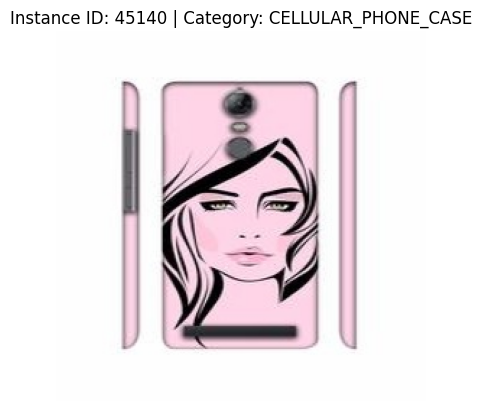


Available columns: ['image_path', 'instance_id', 'domain', 'product_type']


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Loading metadata
metadata_path = os.path.join(path, 'meta.csv')

if os.path.exists(metadata_path):
    df_full = pd.read_csv(metadata_path)
    
    # FILTERING BY CATEGORY
    # Focused on CELLULAR_PHONE_CASE: largest category (88,588 products) with
    # highest duplicate density — ideal for demonstrating DQ detection.
    # Can be scaled to any category or the full 264,904-product catalog
    # for enterprise production use by adjusting the filter and sample size below.
    CATEGORY = "CELLULAR_PHONE_CASE"
    SAMPLE_SIZE = 10  # Increase to 500, 5000, or remove cap for production scale
    
    df = (df_full[df_full['product_type'] == CATEGORY]
          .sample(n=SAMPLE_SIZE, random_state=42)  # random_state=42 for reproducibility
          .reset_index(drop=True))
    
    print(f"✅ Total catalog size      : {len(df_full):,} products")
    print(f"✅ '{CATEGORY}' category   : {len(df_full[df_full['product_type'] == CATEGORY]):,} products")
    print(f"✅ Sample loaded for demo  : {len(df)} products")
else:
    print(f"❌ Could not find {metadata_path}")

# 2. Defining image root
images_root = os.path.join(path, 'images', 'small')

# 3. Displaying first image to validate
# a data validation checkpoint. Before investing compute and API budget processing hundreds of products, 
# a human visually confirms the pipeline is reading the right data correctly
rel_path = df['image_path'].iloc[0]
full_path = os.path.join(images_root, rel_path)
if not os.path.exists(full_path):
    full_path = os.path.join(path, rel_path)
if not os.path.exists(full_path):
    full_path = os.path.join(path, 'images', 'images', os.path.basename(rel_path))

if os.path.exists(full_path):
    print(f"\n✅ Sample image found at: {full_path}")
    img = mpimg.imread(full_path)
    plt.imshow(img)
    plt.title(f"Instance ID: {df['instance_id'].iloc[0]} | Category: {CATEGORY}")
    plt.axis('off')
    plt.show()
else:
    print(f"⚠️ Image not found at: {full_path}")

print(f"\nAvailable columns: {df.columns.tolist()}")

Step 3: Feature Extraction (Layer 2) — Multimodal Fingerprints
implements a two-model multimodal feature extraction architecture: an open-source embedding model runs locally to protect sensitive catalog data, while Claude's vision API converts product images into structured text descriptions — bridging the historic gap where traditional MDM and DQ tools were completely blind to visual data. The resulting fingerprints combine structured metadata with visual intelligence into mathematically comparable vectors, with full intermediate outputs preserved for the explainability and auditability that enterprise data governance requires.

In [4]:
import numpy as np
from PIL import Image as PILImage
from sentence_transformers import SentenceTransformer
import base64
import json

# 1. LOADING TEXT EMBEDDING MODEL (runs locally for free)
print("Loading text embedding model...")
text_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Text embedding model loaded.")

# 2. HELPER: encoding image to base64 for Claude
def encode_image_base64(img_path):
    with open(img_path, "rb") as f:
        return base64.standard_b64encode(f.read()).decode("utf-8")

# 3. IMAGE DESCRIPTION via Claude Vision
def describe_image_with_claude(img_path):
    """Use Claude to generate a text description of the product image."""
    try:
        image_data = encode_image_base64(img_path)
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=256,
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/jpeg",
                            "data": image_data
                        }
                    },
                    {
                        "type": "text",
                        "text": "Describe this product in 2-3 sentences focusing on visual appearance, color, shape, and category. Be concise."
                    }
                ]
            }]
        )
        return response.content[0].text
    except Exception as e:
        return f"No description available: {e}"

# 4. FINGERPRINT FUNCTION
def get_product_fingerprint(row):
    """Generate a combined text+image embedding for a product."""
    rel_path = row['image_path']
    img_path = os.path.join(path, 'images', 'small', rel_path)
    if not os.path.exists(img_path):
        img_path = os.path.join(path, rel_path)
    if not os.path.exists(img_path):
        img_path = os.path.join(path, 'images', 'images', os.path.basename(rel_path))

    # Getting image description from Claude
    if os.path.exists(img_path):
        image_description = describe_image_with_claude(img_path)
        print(f"  📸 Image described: {image_description[:80]}...")
    else:
        image_description = "No image available"

    # Combining text metadata + image description into one string
    combined_text = f"""
    Product Type: {row.get('product_type', 'Unknown')}
    Domain: {row.get('domain', 'Unknown')}
    Visual Description: {image_description}
    """

    # Generating embedding vector from combined text
    embedding = text_model.encode(combined_text)
    return {
        "instance_id": row['instance_id'],
        "combined_text": combined_text.strip(),
        "embedding": embedding,
        "image_description": image_description
    }

# 5. GENERATE FINGERPRINTS FOR ALL SAMPLES
print("\n🔍 Generating multimodal fingerprints...")
fingerprints = []
for _, row in df.iterrows():
    print(f"\nProcessing: {row['instance_id']}")
    fp = get_product_fingerprint(row)
    fingerprints.append(fp)

print(f"\n✅ Generated {len(fingerprints)} product fingerprints.")

Loading text embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Text embedding model loaded.

🔍 Generating multimodal fingerprints...

Processing: 45140
  📸 Image described: ## Phone Case Description

This is a **smartphone back cover/case** featuring a ...

Processing: 85316
  📸 Image described: This is a **smartphone case** designed for a Samsung Galaxy device, featuring a ...

Processing: 43333
  📸 Image described: This is a **smartphone case** featuring a soft **pink background** with an adora...

Processing: 89492
  📸 Image described: This is a **smartphone case** featuring a vibrant, abstract **oil painting-style...

Processing: 59144
  📸 Image described: This is a **smartphone protective case** featuring a striking **deep purple amet...

Processing: 85310
  📸 Image described: This is a **smartphone case** featuring a striking **underwater/water surface de...

Processing: 37844
  📸 Image described: ## Phone Case Description

This is a **slim black smartphone case** featuring a ...

Processing: 42595
  📸 Image described: ## Phone Case Descri

Step 4: Duplicate Detection + HITL Logic (Layer 3)
implements a three-stage intelligent duplicate detection pipeline: cosine similarity across multimodal embeddings identifies candidates at scale, a configurable threshold filters by confidence, and Claude provides structured Golden Record proposals with HITL routing that automatically approves high-confidence merges while escalating uncertain cases to human data stewards — mirroring the governance workflow of enterprise MDM platforms like Informatica, Stibo, and Reltio, but powered by Gen AI instead of rigid rule engines.

📐 Computing similarity matrix...


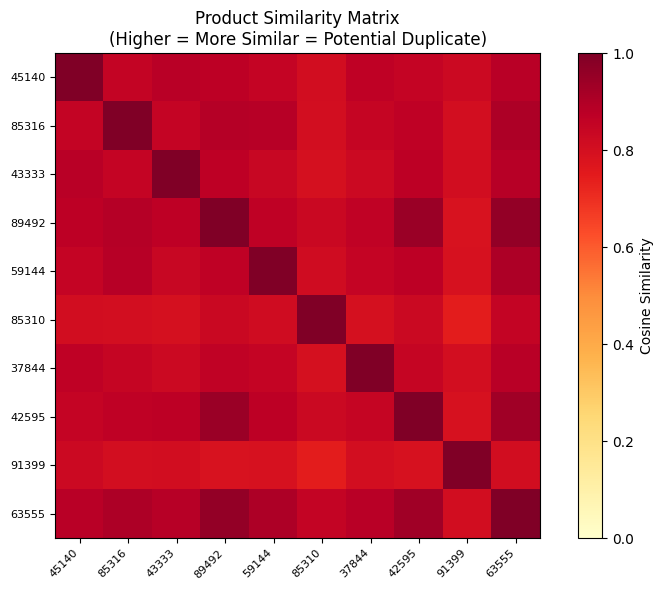


🔎 Found 23 potential duplicate pair(s) above threshold 0.85.

🤖 Claude is reviewing duplicate candidates...

Analyzing: 45140 ↔ 85316 (similarity: 0.85)
{
  "are_duplicates": false,
  "proposed_instance_id": "45140",
  "merged_product_type": "CELLULAR_PHONE_CASE",
  "confidence": 0.95,
  "reasoning": "Despite a high similarity score of 0.85, these products are clearly not duplicates. They differ in multiple key attributes: (1) Device compatibility \u2014 Product A is designed for a Lenovo smartphone, while Product B is designed for a Samsung Galaxy device; (2) Design/aesthetics \u2014 Product A features a pink background with a black line-art illustration of a woman's face, while Product B features a gold glitter texture with a clear/white border; (3) Visual style \u2014 one is minimalist/fashion line-art, the other is glamorous/sparkle. The high similarity score is likely driven by shared high-level attributes such as product type (both are smartphone cases), domain (both on Amazon),

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import json

# 1. COMPUTE SIMILARITY MATRIX
print("📐 Computing similarity matrix...")
embeddings_matrix = np.array([fp['embedding'] for fp in fingerprints])
similarity_matrix = cosine_similarity(embeddings_matrix)

# Displaying similarity heatmap
plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.title('Product Similarity Matrix\n(Higher = More Similar = Potential Duplicate)')
ids = [str(fp['instance_id'])[:12] for fp in fingerprints]  # ← fix here
plt.xticks(range(len(ids)), ids, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(ids)), ids, fontsize=8)
plt.tight_layout()
plt.show()

# 2. FIND DUPLICATE CANDIDATES
SIMILARITY_THRESHOLD = 0.85

duplicate_pairs = []
for i in range(len(fingerprints)):
    for j in range(i + 1, len(fingerprints)):
        score = similarity_matrix[i][j]
        if score >= SIMILARITY_THRESHOLD:
            duplicate_pairs.append((i, j, score))

print(f"\n🔎 Found {len(duplicate_pairs)} potential duplicate pair(s) above threshold {SIMILARITY_THRESHOLD}.")

# 3. CLAUDE HITL: PROPOSE GOLDEN RECORD
def generate_golden_record(fp1, fp2, similarity_score):
    prompt = f"""
    You are a Data Quality AI assistant. Two products have been flagged as potential duplicates 
    with a similarity score of {similarity_score:.2f} (scale 0-1).

    Product A (ID: {fp1['instance_id']}):
    {fp1['combined_text']}

    Product B (ID: {fp2['instance_id']}):
    {fp2['combined_text']}

    Analyze whether these are true duplicates and propose a Golden Record.
    
    Return ONLY a JSON object with this exact structure:
    {{
      "are_duplicates": true or false,
      "proposed_instance_id": "the ID of the better record to keep",
      "merged_product_type": "the best product type label",
      "confidence": a float between 0.0 and 1.0,
      "reasoning": "brief explanation of your decision"
    }}
    """
    try:
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=512,
            messages=[{"role": "user", "content": prompt}]
        )
        clean_json = response.content[0].text.replace('```json', '').replace('```', '').strip()
        proposal = json.loads(clean_json)
        proposal['similarity_score'] = round(float(similarity_score), 4)
        proposal['status'] = "PENDING_REVIEW" if proposal.get('confidence', 0) < 0.90 else "AUTO_READY"
        return proposal
    except Exception as e:
        return {"error": str(e), "status": "FAILED"}

# 4. PROCESS DUPLICATE CANDIDATES
print("\n🤖 Claude is reviewing duplicate candidates...\n")

if duplicate_pairs:
    results = []
    for i, j, score in duplicate_pairs:
        print(f"Analyzing: {fingerprints[i]['instance_id']} ↔ {fingerprints[j]['instance_id']} (similarity: {score:.2f})")
        result = generate_golden_record(fingerprints[i], fingerprints[j], score)
        results.append(result)
        print(json.dumps(result, indent=2))
        print("-" * 60)
else:
    # Analyzing the most similar non-identical pair
    print("No pairs above threshold — running demo on most similar pair...")
    flat = similarity_matrix.copy()
    np.fill_diagonal(flat, 0)  # ← fixed: separate step, no chained or
    i, j = np.unravel_index(flat.argmax(), flat.shape)
    score = similarity_matrix[i][j]
    print(f"Most similar pair: {fingerprints[i]['instance_id']} ↔ {fingerprints[j]['instance_id']} (similarity: {score:.2f})")
    result = generate_golden_record(fingerprints[i], fingerprints[j], score)
    print(json.dumps(result, indent=2))
    results = [result]

# 5. SUMMARY DASHBOARD
print("\n" + "="*60)
print("📊 DATA QUALITY REPORT — DUPLICATE DETECTION SUMMARY")
print("="*60)
print(f"Total products analyzed : {len(fingerprints)}")
print(f"Duplicate pairs flagged : {len(duplicate_pairs)}")
print(f"Auto-ready merges       : {sum(1 for r in results if r.get('status') == 'AUTO_READY')}")
print(f"Pending human review    : {sum(1 for r in results if r.get('status') == 'PENDING_REVIEW')}")
print(f"Failed                  : {sum(1 for r in results if r.get('status') == 'FAILED')}")
print("="*60)

Step 5: Lineage Tracking (Layer 4)
implements the data governance layer using a normalized two-table SQLite schema that mirrors the lineage storage architecture of enterprise platforms like Apache Atlas and Collibra — permanently recording every AI merge decision with its source provenance, input records, confidence score, Claude's reasoning, and pipeline version, creating the immutable audit trail required by data governance frameworks like DAMA-DMBOK and emerging AI regulations like the EU AI Act's Article 12 logging requirements.

In [6]:
import sqlite3
import json
import datetime
import os

# 1. SETUP LINEAGE DATABASE
DB_PATH = os.path.join(os.path.dirname(path), "data_lineage.db")

def init_lineage_db(db_path):
    # Initializing lineage tracking database — mimics a corporate data catalog
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.executescript("""
        CREATE TABLE IF NOT EXISTS lineage_sources (
            source_id       TEXT PRIMARY KEY,
            source_name     TEXT NOT NULL,
            source_type     TEXT NOT NULL,
            source_url      TEXT,
            created_at      TEXT NOT NULL
        );

        CREATE TABLE IF NOT EXISTS lineage_events (
            event_id            TEXT PRIMARY KEY,
            event_type          TEXT NOT NULL,
            source_id           TEXT NOT NULL,
            input_instance_ids  TEXT NOT NULL,
            output_instance_id  TEXT NOT NULL,
            merged_product_type TEXT,
            confidence          REAL,
            status              TEXT,
            reasoning           TEXT,
            similarity_score    REAL,
            pipeline_version    TEXT,
            created_at          TEXT NOT NULL,
            FOREIGN KEY (source_id) REFERENCES lineage_sources(source_id)
        );
    """)
    conn.commit()
    return conn

conn = init_lineage_db(DB_PATH)
print(f"✅ Lineage database initialized at: {DB_PATH}")

# 2. REGISTER DATA SOURCE
def register_source(conn, source_id, name, source_type, url):
    # Registering the origin dataset — equivalent to registering a source in Collibra/Dataplex.
    cursor = conn.cursor()
    cursor.execute("""
        INSERT OR REPLACE INTO lineage_sources 
        (source_id, source_name, source_type, source_url, created_at)
        VALUES (?, ?, ?, ?, ?)
    """, (source_id, name, source_type, url, datetime.datetime.utcnow().isoformat()))
    conn.commit()
    print(f"📌 Source registered: [{source_type}] {name}")

register_source(
    conn,
    source_id="abo-kaggle-v2",
    name="Amazon Berkeley Objects (ABO) Dataset",
    source_type="KAGGLE_DATASET",
    url="https://www.kaggle.com/datasets/khyeh0719/amazon-berkley-product-dataset"
)

# 3. RECORD LINEAGE EVENTS
def record_lineage_event(conn, result, input_fingerprints):
    # Recording a Golden Record merge event.
    # Each event traces: Source Dataset → Raw Products → Golden Record
    # This is the core of data lineage: knowing WHERE data came from and HOW it was transformed.
    if result.get('status') == 'FAILED':
        print(f"⚠️  Skipping failed result: {result.get('error', 'unknown error')}")
        return None

    event_id = f"evt_{datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S%f')}"
    input_ids = json.dumps([str(fp['instance_id']) for fp in input_fingerprints])

    cursor = conn.cursor()
    cursor.execute("""
        INSERT INTO lineage_events (
            event_id, event_type, source_id, input_instance_ids,
            output_instance_id, merged_product_type, confidence,
            status, reasoning, similarity_score, pipeline_version, created_at
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        event_id,
        "GOLDEN_RECORD_MERGE",
        "abo-kaggle-v2",
        input_ids,
        str(result.get('proposed_instance_id', 'unknown')),
        result.get('merged_product_type', 'unknown'),
        result.get('confidence', 0.0),
        result.get('status', 'UNKNOWN'),
        result.get('reasoning', ''),
        result.get('similarity_score', 0.0),
        "1.0.0",
        datetime.datetime.utcnow().isoformat()
    ))
    conn.commit()
    print(f"✅ Lineage event recorded: {event_id}")
    return event_id

# Recording all results from Step 4
print("\n📝 Recording lineage events...\n")
for result in results:
    record_lineage_event(conn, result, fingerprints)

# 4. AUDIT QUERY
print("\n" + "="*60)
print("🔍 LINEAGE AUDIT TRAIL")
print("="*60)

cursor = conn.cursor()
cursor.execute("""
    SELECT 
        e.event_id,
        s.source_name,
        e.input_instance_ids,
        e.output_instance_id,
        e.merged_product_type,
        e.confidence,
        e.status,
        e.similarity_score,
        e.created_at
    FROM lineage_events e
    JOIN lineage_sources s ON e.source_id = s.source_id
    ORDER BY e.created_at DESC
""")

rows = cursor.fetchall()
columns = ['Event ID', 'Source', 'Inputs', 'Golden Record', 
           'Product Type', 'Confidence', 'Status', 'Similarity', 'Timestamp']

audit_df = pd.DataFrame(rows, columns=columns)
print(audit_df.to_string(index=False))

# 5. LINEAGE SUMMARY
print("\n" + "="*60)
print("📊 LINEAGE SUMMARY")
print("="*60)
cursor.execute("SELECT COUNT(*) FROM lineage_events")
total = cursor.fetchone()[0]
cursor.execute("SELECT COUNT(*) FROM lineage_events WHERE status = 'AUTO_READY'")
auto = cursor.fetchone()[0]
cursor.execute("SELECT COUNT(*) FROM lineage_events WHERE status = 'PENDING_REVIEW'")
pending = cursor.fetchone()[0]
cursor.execute("SELECT AVG(confidence) FROM lineage_events")
avg_conf = cursor.fetchone()[0] or 0

print(f"Total lineage events   : {total}")
print(f"Auto-approved merges   : {auto}")
print(f"Pending human review   : {pending}")
print(f"Avg merge confidence   : {avg_conf:.2%}")
print(f"Lineage DB location    : {DB_PATH}")
print("="*60)

conn.close()
print("\n✅ Lineage tracking complete. Audit trail saved to SQLite.")

✅ Lineage database initialized at: C:\Users\alejandro.uriber\.cache\kagglehub\datasets\khyeh0719\amazon-berkley-product-dataset\versions\data_lineage.db
📌 Source registered: [KAGGLE_DATASET] Amazon Berkeley Objects (ABO) Dataset

📝 Recording lineage events...

✅ Lineage event recorded: evt_20260402_193548845709
✅ Lineage event recorded: evt_20260402_193548851579
✅ Lineage event recorded: evt_20260402_193548857849
✅ Lineage event recorded: evt_20260402_193548864826
✅ Lineage event recorded: evt_20260402_193548871891
✅ Lineage event recorded: evt_20260402_193548878646
✅ Lineage event recorded: evt_20260402_193548885215
✅ Lineage event recorded: evt_20260402_193548892599
✅ Lineage event recorded: evt_20260402_193548898739
✅ Lineage event recorded: evt_20260402_193548904793
✅ Lineage event recorded: evt_20260402_193548910295
✅ Lineage event recorded: evt_20260402_193548915958
✅ Lineage event recorded: evt_20260402_193548921663
✅ Lineage event recorded: evt_20260402_193548927462
✅ Lineage e

C:\Users\alejandro.uriber\AppData\Local\Temp\ipykernel_24028\3830424615.py:52: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  """, (source_id, name, source_type, url, datetime.datetime.utcnow().isoformat()))
C:\Users\alejandro.uriber\AppData\Local\Temp\ipykernel_24028\3830424615.py:73: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  event_id = f"evt_{datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S%f')}"
C:\Users\alejandro.uriber\AppData\Local\Temp\ipykernel_24028\3830424615.py:95: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime